hi, this is raymond.

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Just to get the files
major_folder = 'data'

for file in os.listdir(major_folder):
    filepath = os.path.join(major_folder, file)
    print(filepath)

data/[Provincial] Reduction - Cebu - Section VI (R).csv
data/[Provincial] Reduction - Cebu - Phase 2B-Year 2 & 3 (R).csv
data/[Provincial] Reduction - Cebu - Section III (R).csv
data/[Provincial] Reduction - Cebu - Section II (R).csv
data/[Provincial] Reduction - Cebu - Section VII (R).csv
data/[Provincial] Reduction - Cebu - Section IV (R).csv
data/[Provincial] Reduction - Cebu - Section V (R).csv
data/~$consolidated_data.xlsx
data/[Provincial] Reduction - Cebu - Phase 1B (R).csv
data/[Provincial] Reduction - Cebu - Section I (R).csv
data/consolidated_data.xlsx


# Phase IB - Labor Demand

The stacked bar chart below shows the labor demand across sectors. Construction and manufacturing sectors have the highest number of jobs, but the urgency of these roles varies. Jobs are classified as high priority if 500 or more workers are needed, medium priority if 100–499 workers are required, and low priority if fewer than 100 workers are needed within the next 1–3 years. In construction, most positions are low or medium priority, suggesting that while many roles exist, few are immediately urgent. Manufacturing, however, has a substantial share of high-priority jobs, highlighting positions that companies need quickly and in large numbers.

This distinction is critical for TESDA Cebu’s planning. The chart reflects the number of distinct job titles, not the total labor demand, meaning sectors with many medium-priority roles could still require a large workforce overall. To ensure resources are invested wisely (whether through proper allocation of student scholarships, new training programs, or expanded centers), TESDA should look beyond the counts of the job and consider actual workforce needs.

In [3]:
# Open up phase 1b
phase_1b = 'data/[Provincial] Reduction - Cebu - Phase 1B (R).csv'

pretty_phase_1b_names = {
    'Program\nType':'Program Type', 
    'Priority\nRanking\n(Province)':'Priority Ranking (Province)', 
    'For Supermarket\n(Dropdown Selection)' : "For Supermarket (Dropdown Selection)"
}

# Select columns 3 to 10 and column 12 (0-indexed)
cols_to_keep = np.r_[3:10, 11]  
phase_1b_df = pd.read_csv(phase_1b, header=1).rename(columns=pretty_phase_1b_names).iloc[:, cols_to_keep]

# Define the desired order
priority_order = ['HIGH', 'MEDIUM', 'LOW']

# Convert the column to an ordered categorical
phase_1b_df['Priority Ranking (Province)'] = pd.Categorical(
    phase_1b_df['Priority Ranking (Province)'],
    categories=priority_order,
    ordered=True
)


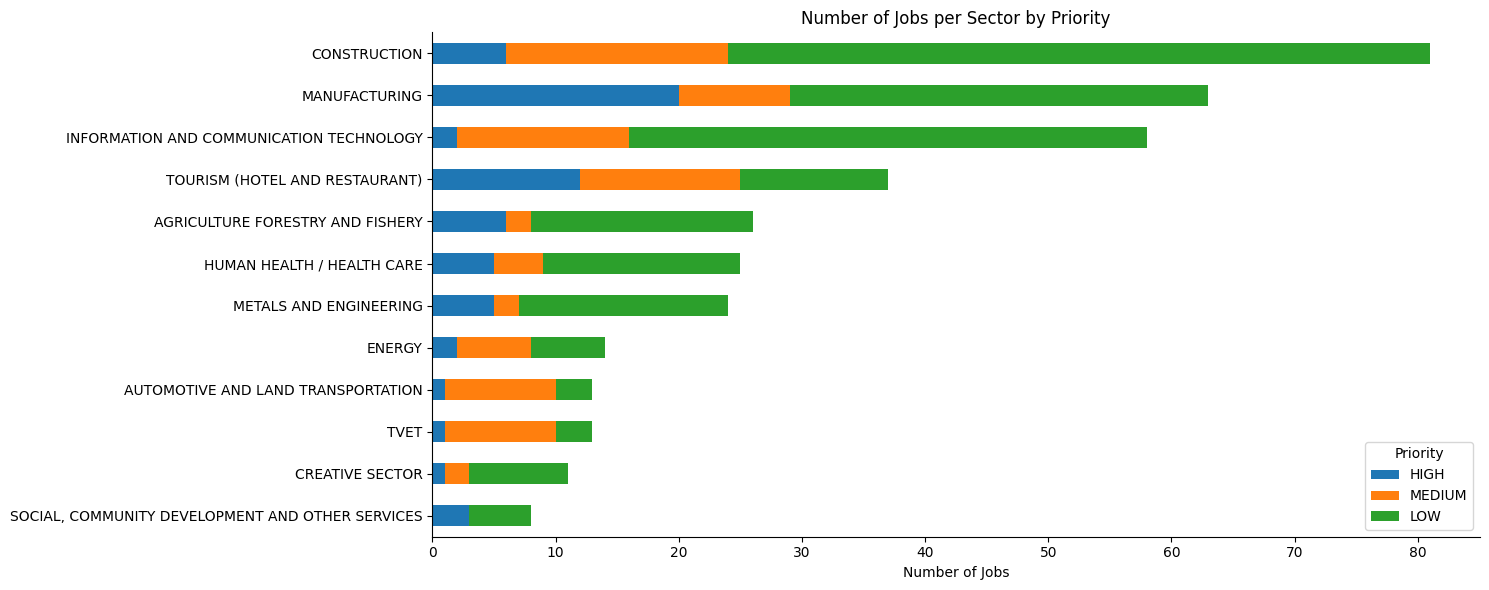

In [13]:
# Create crosstab
sector_priority = pd.crosstab(
    phase_1b_df['Sector'],
    phase_1b_df['Priority Ranking (Province)']
)

# Filter out sectors with very few jobs
sector_priority = sector_priority[sector_priority.sum(axis=1) > 5]

# Sort sectors by total jobs (sum of all priorities) in descending order
sector_priority['Total'] = sector_priority.sum(axis=1)
sector_priority = sector_priority.sort_values('Total', ascending=False)
sector_priority = sector_priority.drop(columns='Total')

# Define colors
colors = {'HIGH': '#1f77b4', 'MEDIUM': '#ff7f0e', 'LOW': '#2ca02c'}

# Plot horizontal stacked bar chart
sector_priority.plot(
    kind='barh',
    stacked=True,
    color=[colors[col] for col in sector_priority.columns],
    figsize=(15,6)
)

plt.title('Number of Jobs per Sector by Priority')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.legend(title='Priority')
#plt.legend(title='Priority', bbox_to_anchor=(1.05, 1))
plt.gca().invert_yaxis()  # Highest total jobs on top

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# Section 1 - TESDA properly allocates the available scholarships to the priority jobs.

The grouped bar chart below shows the number of targeted scholars across sectors for Year 2 and Year 3. Construction, Tourism (Hotel & Restaurant), Manufacturing, and ICT receive the highest number of scholars, reflecting TESDA’s alignment of labor supply with sectoral demand. Most sectors show similar numbers between the two years, indicating a consistent proportional allocation of scholars rather than arbitrary changes. Smaller sectors, such as Furniture & Fixtures or Processed Food & Beverages, receive fewer scholars, which corresponds to their relatively lower labor demand.

This distinction is important for TESDA Cebu’s planning. TESDA appears to be effectively assigning scholarships, focusing on sectors and roles that are high priority, ensuring that the supply of trained workers matches the jobs most in demand.

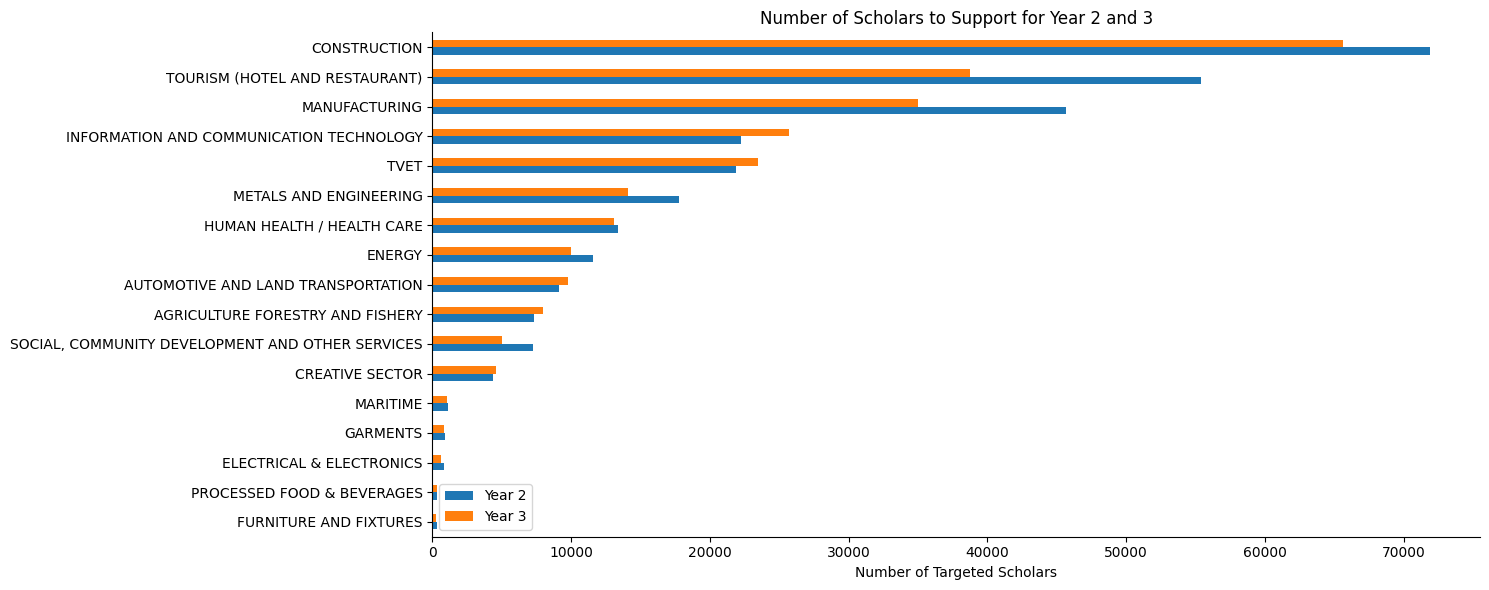

In [15]:
section_1 = 'data/[Provincial] Reduction - Cebu - Section I (R).csv'
section_1_df = pd.read_csv(section_1, header=2).iloc[2:]

# Convert the numeric vols
cols_to_convert = ['Target Beneficiaries', 'Target Beneficiaries.1']
for col in cols_to_convert:
    section_1_df[col] = pd.to_numeric(
        section_1_df[col].str.replace(',', ''), errors='coerce'
    ).fillna(0).astype(int)


# Group once
grouped = section_1_df.groupby('Sector')[['Target Beneficiaries', 'Target Beneficiaries.1']].sum()

# Plot grouped horizontal bar chart
grouped = grouped.sort_values(by='Target Beneficiaries')

grouped.plot(kind='barh', figsize=(15, 6), color=['#1f77b4', '#ff7f0e'])

plt.xlabel('Number of Targeted Scholars')
plt.ylabel('')
plt.title('Number of Scholars to Support for Year 2 and 3')
plt.legend(['Year 2', 'Year 3'])

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


# Section 2 - The number of institutions for teaching matches the labor demand and supply. However, there is a lag since there are less institutions for year 2 (94 in total) compared to year 3 (257 in total).

The grouped bar chart below shows the number of training institutions across sectors for Year 2 and Year 3. Tourism, Construction, Manufacturing, and ICT consistently have the highest number of institutions, indicating TESDA’s sustained support for sectors with high labor demand. Year-to-year fluctuations are minor, and most sectors show similar numbers across both years, reflecting a steady, proportional allocation rather than arbitrary changes. Smaller sectors, such as Furniture & Fixtures or Processed Food & Beverages, continue to receive fewer institutions, consistent with their lower workforce needs. Overall, TESDA Cebu appears to maintain a balanced distribution of training capacity, ensuring that the supply of skilled workers aligns with sectoral demand.

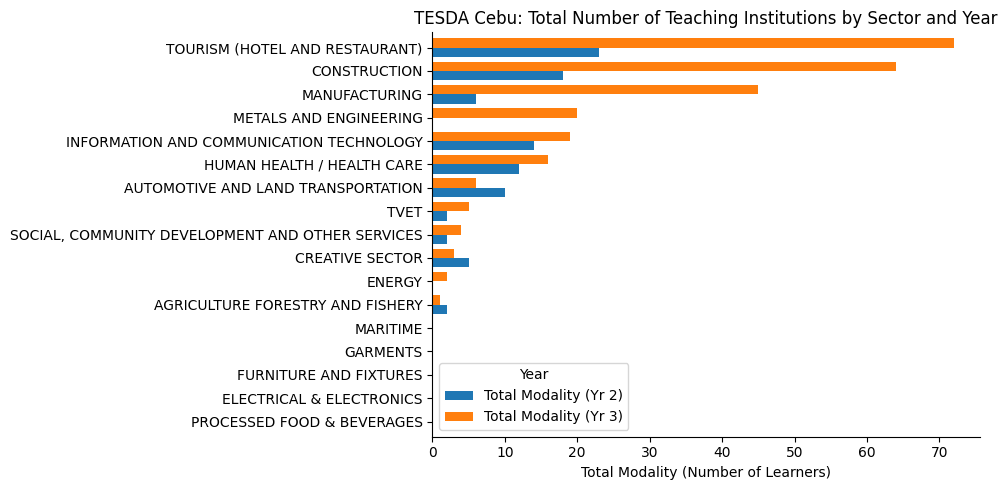

In [67]:
#
section_2 = 'data/[Provincial] Reduction - Cebu - Section II (R).csv'
section_2_df = pd.read_csv(section_2, header=1, skiprows=2)

section_2_df = section_2_df.rename(columns={
    'Unnamed: 3': 'Sector',
    'Unnamed: 13': 'Total Modality (Yr 2)',
    'Unnamed: 22': 'Total Modality (Yr 3)'
})

# Convert the renamed columns to integers
section_2_df['Total Modality (Yr 2)'] = section_2_df['Total Modality (Yr 2)'].astype(int)
section_2_df['Total Modality (Yr 3)'] = section_2_df['Total Modality (Yr 3)'].astype(int)

# Group by Sector and sum
grouped = section_2_df.groupby('Sector')[['Total Modality (Yr 2)','Total Modality (Yr 3)']].sum().sort_values(by='Total Modality (Yr 3)')


ax = grouped[['Total Modality (Yr 2)', 'Total Modality (Yr 3)']].plot(kind='barh', figsize=(10, 5), width=0.8)
ax.set_xlabel("Total Modality (Number of Learners)")
ax.set_ylabel("")
ax.set_title("TESDA Cebu: Total Number of Teaching Institutions by Sector and Year")
plt.legend(title="Year")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# Section 3 - Three partners were found to help with the new and emerging jobs in the Industry and Healthcare sectors.



This table shows TESDA Cebu’s support for emerging jobs, with priority levels indicating the urgency of labor demand. Training providers include medical institutions and industry associations. Interestingly, every job has an identical budget of PHP 474,700, which is unusual and raises questions about the accuracy or rationale behind these allocations.

| Job Title                           | Priority | Training Provider(s)                                                                                    | Budget (PHP) |
| ----------------------------------- | -------- | ------------------------------------------------------------------------------------------------------- | ------------ |
| Industrial Sewing Machine Operators | Low      | MetrologyX Training and Assessment Center Inc.                                                          | 474,700      |
| Medical Auxiliary Support           | High     | The Hospital at Maayo (THAM), San Lucas Medical (SLM)                                                   | 474,700      |
| Medical Receptionist                | High     | Department of Health (DOH), Philippine Medical Association (PMA), Philippine Hospital Association (PHA) | 474,700      |
| Boiler Technicians                  | Low      | Hotel Resort and Restaurant Association of Cebu, Inc.                                                   | 474,700      |
| Community-Based Trainers            | Low      | Department of Health (DOH), Philippine Medical Association (PMA), Philippine Hospital Association (PHA) | 474,700      |
| Medical Secretary                   | High     | Department of Health (DOH), Philippine Medical Association (PMA), Philippine Hospital Association (PHA) | 474,700      |


In [ ]:
section_4 = 'data/[Provincial] Reduction - Cebu - Section IV (R).csv'
section_4_df = pd.read_csv(section_4)